# Assignment 3 — Predicting Car Price (Classification)

**Course:** AT82.03 Machine Learning &nbsp;·&nbsp; **Student:** Chidsanuphong Pengchai — `st127004`

In A1/A2 we predicted the car's selling price as a **regression** problem. Here we reuse the
**same preprocessed dataset** but treat it as a **4-class classification** problem, implement
**multinomial logistic regression from scratch** (based on the class notebook
*02 - Multinomial Logistic Regression*), hand-code every classification metric, add an optional
**Ridge (L2) penalty**, and run an **MLflow** experiment.

This notebook is **self-contained** — every piece of model, metric, and experiment code is written
inline below. (The same code also lives in `logistic_regression.py` / `a3_experiment.py` so the web
app and the unit tests can import it.)

| Task | What it covers |
|---|---|
| **Task 1** | Bucket price into 4 classes · from-scratch `accuracy`, per-class `precision`/`recall`/`f1`, `macro_*`, `weighted_*` · compare to sklearn · explain *support* |
| **Task 2** | Optional Ridge (L2) penalty on the logistic loss |
| **Task 3** | MLflow logging (local — CSIM server down, see README) · model registry (deferred) · CI/CD with GitHub Actions |

> **Note on the MLflow server.** Per the TA's notice, `mlflow.ml.brain.cs.ait.ac.th` is currently
> down. As instructed, Objective 1 logs the experiment **locally** (sqlite) in the meantime; the
> only change needed once the server returns is the `tracking_uri`. Objective 2 (model registry) is
> deferred pending further instructions. Objective 3 (CI/CD) does not depend on the server and is
> completed.


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from itertools import product
from pathlib import Path
from typing import Any, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
pd.set_option("display.width", 120)
np.set_printoptions(suppress=True)

# Task 1 — Classification

## 1.1 The from-scratch multinomial `LogisticRegression`

Everything the assignment asks for lives in this one class:

* **softmax**, **one-hot** encoding, the **cross-entropy** loss and its **gradient**, and the three
  gradient-descent flavours (`batch` / `minibatch` / `stochastic`) — based on the class notebook.
* the **Ridge (L2) penalty** (Task 2), switched on with `use_penalty=True`.
* every **metric** implemented by hand: `accuracy`, per-class `precision` / `recall` / `f1`, and
  their `macro_*` and `weighted_*` averages, plus a `classification_report` that mirrors sklearn.

The code below is the exact class used by the web app and the unit tests.

In [2]:
from __future__ import annotations

from typing import Any, Sequence

import numpy as np


class LogisticRegression:
    """Multinomial (softmax) logistic regression trained with gradient descent.

    Args:
        method: Gradient-descent flavour: ``batch``, ``minibatch`` or
            ``stochastic`` (mirrors the class notebook).
        learning_rate: Step size for the weight update ``W := W - lr * grad``.
        max_iter: Number of gradient-descent iterations.
        use_penalty: If ``True`` add the Ridge (L2) penalty to the loss and its
            gradient. This is the Task 2 switch — ``False`` reproduces plain
            multinomial logistic regression.
        lambda_: Ridge penalty strength ``λ`` (only used when ``use_penalty``).
        batch_size: Samples per update when ``method="minibatch"``.
        random_state: Seed for weight initialisation and batch sampling.
    """

    VALID_METHODS = {"batch", "minibatch", "stochastic"}

    def __init__(
        self,
        method: str = "batch",
        learning_rate: float = 0.01,
        max_iter: int = 5000,
        use_penalty: bool = False,
        lambda_: float = 0.1,
        batch_size: int = 64,
        random_state: int = 42,
    ) -> None:
        self.method = method
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.use_penalty = use_penalty
        self.lambda_ = lambda_
        self.batch_size = batch_size
        self.random_state = random_state

    # ------------------------------------------------------------------ #
    # scikit-learn compatibility (lets us reuse cross_val_score, GridSearch)
    # ------------------------------------------------------------------ #
    def get_params(self, deep: bool = True) -> dict[str, Any]:
        """Return constructor parameters (scikit-learn estimator protocol)."""
        del deep
        return {
            "method": self.method,
            "learning_rate": self.learning_rate,
            "max_iter": self.max_iter,
            "use_penalty": self.use_penalty,
            "lambda_": self.lambda_,
            "batch_size": self.batch_size,
            "random_state": self.random_state,
        }

    def set_params(self, **params: Any) -> "LogisticRegression":
        """Set constructor parameters (scikit-learn estimator protocol)."""
        for name, value in params.items():
            if name not in self.get_params():
                raise ValueError(f"Unknown parameter: {name}")
            setattr(self, name, value)
        return self

    # ------------------------------------------------------------------ #
    # Core maths: softmax, one-hot, loss, gradient
    # ------------------------------------------------------------------ #
    @staticmethod
    def _add_intercept(features: np.ndarray) -> np.ndarray:
        """Prepend a column of ones so w[0] acts as the per-class bias term."""
        ones = np.ones((features.shape[0], 1), dtype=float)
        return np.concatenate([ones, features], axis=1)

    @staticmethod
    def softmax(scores: np.ndarray) -> np.ndarray:
        """Row-wise softmax turning class scores into a probability distribution.

        The max is subtracted before exponentiating for numerical stability —
        this cannot change the result because softmax is shift-invariant.
        """
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exponentiated = np.exp(shifted)
        return exponentiated / np.sum(exponentiated, axis=1, keepdims=True)

    @staticmethod
    def _one_hot(labels: np.ndarray, number_of_classes: int) -> np.ndarray:
        """Encode integer labels as an (m, k) matrix with a single 1 per row."""
        encoded = np.zeros((labels.shape[0], number_of_classes), dtype=float)
        encoded[np.arange(labels.shape[0]), labels] = 1.0
        return encoded

    def _loss_and_gradient(
        self, features: np.ndarray, one_hot_target: np.ndarray
    ) -> tuple[float, np.ndarray]:
        """Cross-entropy loss (+ optional ridge) and its gradient w.r.t. W."""
        sample_count = features.shape[0]
        probabilities = self.softmax(features @ self.weights)
        # Cross-entropy: -sum(Y * log(h)) / m. The clip avoids log(0).
        log_likelihood = -np.sum(
            one_hot_target * np.log(np.clip(probabilities, 1e-15, 1.0))
        ) / sample_count
        gradient = features.T @ (probabilities - one_hot_target) / sample_count

        if self.use_penalty:
            # Ridge / L2: J += λ * Σ θ².  The bias row (index 0) is excluded so
            # we regularise slopes only, which is the standard convention.
            penalised = self.weights.copy()
            penalised[0, :] = 0.0
            log_likelihood += self.lambda_ * float(np.sum(penalised**2))
            gradient += 2.0 * self.lambda_ * penalised

        return float(log_likelihood), gradient

    # ------------------------------------------------------------------ #
    # Training
    # ------------------------------------------------------------------ #
    def _iter_batches(
        self, feature_count: int, generator: np.random.Generator
    ) -> np.ndarray:
        """Return the row indices used for a single gradient-descent update."""
        if self.method == "batch":
            return np.arange(feature_count)
        if self.method == "stochastic":
            return generator.integers(0, feature_count, size=1)
        size = min(self.batch_size, feature_count)
        return generator.choice(feature_count, size=size, replace=False)

    def fit(
        self,
        features: np.ndarray,
        target: np.ndarray,
        feature_names: Sequence[str] | None = None,
    ) -> "LogisticRegression":
        """Fit softmax weights on preprocessed features and integer labels."""
        if self.method not in self.VALID_METHODS:
            raise ValueError(f"method must be one of {sorted(self.VALID_METHODS)}")
        if self.learning_rate <= 0:
            raise ValueError("learning_rate must be positive")
        if self.max_iter <= 0:
            raise ValueError("max_iter must be positive")
        if self.use_penalty and self.lambda_ < 0:
            raise ValueError("lambda_ cannot be negative")

        feature_array = np.asarray(features, dtype=float)
        label_array = np.asarray(target).reshape(-1)
        if feature_array.ndim != 2:
            raise ValueError("features must be a two-dimensional array")
        if len(feature_array) != len(label_array) or len(label_array) == 0:
            raise ValueError("features and target must share the same non-zero length")

        # Map raw labels to 0..k-1 so one-hot encoding and argmax line up even if
        # the incoming classes are, say, [1, 2, 3, 4] rather than [0, 1, 2, 3].
        self.classes_ = np.unique(label_array)
        class_to_index = {label: index for index, label in enumerate(self.classes_)}
        indexed_labels = np.array([class_to_index[label] for label in label_array])
        number_of_classes = len(self.classes_)

        design = self._add_intercept(feature_array)
        one_hot_target = self._one_hot(indexed_labels, number_of_classes)

        base_names = list(feature_names) if feature_names is not None else [
            f"x{i}" for i in range(feature_array.shape[1])
        ]
        if len(base_names) != feature_array.shape[1]:
            raise ValueError("feature_names must match the input column count")
        self.feature_names_out_ = base_names

        generator = np.random.default_rng(self.random_state)
        # Small random weights break the symmetry between classes.
        self.weights = generator.normal(
            0.0, 0.01, size=(design.shape[1], number_of_classes)
        )
        self.loss_history_ = []
        history_interval = max(1, self.max_iter // 50)

        for iteration in range(self.max_iter):
            batch_indices = self._iter_batches(len(design), generator)
            batch_features = design[batch_indices]
            batch_target = one_hot_target[batch_indices]
            _, gradient = self._loss_and_gradient(batch_features, batch_target)
            self.weights -= self.learning_rate * gradient

            if iteration % history_interval == 0 or iteration == self.max_iter - 1:
                full_loss, _ = self._loss_and_gradient(design, one_hot_target)
                self.loss_history_.append(full_loss)

        self.n_features_in_ = feature_array.shape[1]
        return self

    def predict_proba(self, features: np.ndarray) -> np.ndarray:
        """Return the (m, k) class-probability matrix for new samples."""
        if not hasattr(self, "weights"):
            raise RuntimeError("fit must be called before predict_proba")
        feature_array = np.asarray(features, dtype=float)
        if feature_array.ndim != 2 or feature_array.shape[1] != self.n_features_in_:
            raise ValueError("features do not match the fitted input shape")
        return self.softmax(self._add_intercept(feature_array) @ self.weights)

    def predict(self, features: np.ndarray) -> np.ndarray:
        """Return the most probable class label for each sample."""
        winning_index = np.argmax(self.predict_proba(features), axis=1)
        return self.classes_[winning_index]

    # ------------------------------------------------------------------ #
    # Task 1 metrics — implemented from scratch
    # ------------------------------------------------------------------ #
    @staticmethod
    def _unique_labels(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        return np.unique(np.concatenate([np.asarray(y_true).reshape(-1),
                                         np.asarray(y_pred).reshape(-1)]))

    @staticmethod
    def accuracy(y_true: Sequence, y_pred: Sequence) -> float:
        """Correct predictions / all predictions."""
        true_array = np.asarray(y_true).reshape(-1)
        pred_array = np.asarray(y_pred).reshape(-1)
        if true_array.shape != pred_array.shape:
            raise ValueError("y_true and y_pred must have the same shape")
        return float(np.mean(true_array == pred_array))

    @classmethod
    def _per_class_counts(
        cls, y_true: Sequence, y_pred: Sequence
    ) -> dict[Any, dict[str, int]]:
        """Return TP, FP, FN and support (true count) for every class."""
        true_array = np.asarray(y_true).reshape(-1)
        pred_array = np.asarray(y_pred).reshape(-1)
        counts: dict[Any, dict[str, int]] = {}
        for label in cls._unique_labels(true_array, pred_array):
            true_positive = int(np.sum((pred_array == label) & (true_array == label)))
            false_positive = int(np.sum((pred_array == label) & (true_array != label)))
            false_negative = int(np.sum((pred_array != label) & (true_array == label)))
            support = int(np.sum(true_array == label))
            counts[label] = {
                "tp": true_positive,
                "fp": false_positive,
                "fn": false_negative,
                "support": support,
            }
        return counts

    @classmethod
    def precision(cls, y_true: Sequence, y_pred: Sequence) -> dict[Any, float]:
        """precision_c = TP_c / (TP_c + FP_c) for each class c."""
        return {
            label: (c["tp"] / (c["tp"] + c["fp"]) if (c["tp"] + c["fp"]) else 0.0)
            for label, c in cls._per_class_counts(y_true, y_pred).items()
        }

    @classmethod
    def recall(cls, y_true: Sequence, y_pred: Sequence) -> dict[Any, float]:
        """recall_c = TP_c / (TP_c + FN_c) for each class c."""
        return {
            label: (c["tp"] / (c["tp"] + c["fn"]) if (c["tp"] + c["fn"]) else 0.0)
            for label, c in cls._per_class_counts(y_true, y_pred).items()
        }

    @classmethod
    def f1(cls, y_true: Sequence, y_pred: Sequence) -> dict[Any, float]:
        """f1_c = 2 * precision_c * recall_c / (precision_c + recall_c)."""
        precision = cls.precision(y_true, y_pred)
        recall = cls.recall(y_true, y_pred)
        scores: dict[Any, float] = {}
        for label in precision:
            p, r = precision[label], recall[label]
            scores[label] = (2 * p * r / (p + r)) if (p + r) else 0.0
        return scores

    # -- macro averages: unweighted mean across classes ---------------- #
    @classmethod
    def macro_precision(cls, y_true: Sequence, y_pred: Sequence) -> float:
        values = list(cls.precision(y_true, y_pred).values())
        return float(np.mean(values)) if values else 0.0

    @classmethod
    def macro_recall(cls, y_true: Sequence, y_pred: Sequence) -> float:
        values = list(cls.recall(y_true, y_pred).values())
        return float(np.mean(values)) if values else 0.0

    @classmethod
    def macro_f1(cls, y_true: Sequence, y_pred: Sequence) -> float:
        values = list(cls.f1(y_true, y_pred).values())
        return float(np.mean(values)) if values else 0.0

    # -- weighted averages: weight each class by its support ----------- #
    @classmethod
    def _weighted(cls, per_class: dict[Any, float], y_true: Sequence) -> float:
        true_array = np.asarray(y_true).reshape(-1)
        total = true_array.shape[0]
        if total == 0:
            return 0.0
        weighted_sum = 0.0
        for label, score in per_class.items():
            support = float(np.sum(true_array == label))
            weighted_sum += (support / total) * score
        return float(weighted_sum)

    @classmethod
    def weighted_precision(cls, y_true: Sequence, y_pred: Sequence) -> float:
        return cls._weighted(cls.precision(y_true, y_pred), y_true)

    @classmethod
    def weighted_recall(cls, y_true: Sequence, y_pred: Sequence) -> float:
        return cls._weighted(cls.recall(y_true, y_pred), y_true)

    @classmethod
    def weighted_f1(cls, y_true: Sequence, y_pred: Sequence) -> float:
        return cls._weighted(cls.f1(y_true, y_pred), y_true)

    @classmethod
    def classification_report(
        cls, y_true: Sequence, y_pred: Sequence, digits: int = 4
    ) -> str:
        """Reproduce sklearn's classification_report layout from scratch.

        ``support`` is the number of ground-truth samples for each class — i.e.
        how many rows actually belong to that class in ``y_true``. It tells you
        how much each per-class score should be trusted and is exactly the
        weight used by the weighted averages.
        """
        precision = cls.precision(y_true, y_pred)
        recall = cls.recall(y_true, y_pred)
        f1 = cls.f1(y_true, y_pred)
        counts = cls._per_class_counts(y_true, y_pred)
        total_support = sum(c["support"] for c in counts.values())

        header = f"{'':>12}{'precision':>12}{'recall':>12}{'f1-score':>12}{'support':>12}"
        lines = [header, ""]
        for label in sorted(precision):
            lines.append(
                f"{str(label):>12}{precision[label]:>12.{digits}f}"
                f"{recall[label]:>12.{digits}f}{f1[label]:>12.{digits}f}"
                f"{counts[label]['support']:>12d}"
            )
        lines.append("")
        lines.append(
            f"{'accuracy':>12}{'':>12}{'':>12}"
            f"{cls.accuracy(y_true, y_pred):>12.{digits}f}{total_support:>12d}"
        )
        lines.append(
            f"{'macro avg':>12}{cls.macro_precision(y_true, y_pred):>12.{digits}f}"
            f"{cls.macro_recall(y_true, y_pred):>12.{digits}f}"
            f"{cls.macro_f1(y_true, y_pred):>12.{digits}f}{total_support:>12d}"
        )
        lines.append(
            f"{'weighted avg':>12}{cls.weighted_precision(y_true, y_pred):>12.{digits}f}"
            f"{cls.weighted_recall(y_true, y_pred):>12.{digits}f}"
            f"{cls.weighted_f1(y_true, y_pred):>12.{digits}f}{total_support:>12d}"
        )
        return "\n".join(lines)


## 1.2 Load the *preprocessed* dataset and bucket the price into 4 classes

We reuse the exact A1/A2 cleaning: map `owner` to an ordinal, drop CNG/LPG and test-drive cars,
strip units off `mileage`/`engine`/`max_power`, derive `brand` from `name`, drop duplicates. Then we
turn the continuous `selling_price` into **4 ordered classes** with `pd.qcut` (equal-frequency
quartiles) so each class holds ~25% of the cars — a balanced problem.

In [3]:
NUMERIC_FEATURES = ["year", "km_driven", "mileage", "engine", "max_power", "seats", "owner"]
CATEGORICAL_FEATURES = ["fuel", "seller_type", "transmission", "brand"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
OWNER_MAP = {"First Owner": 1, "Second Owner": 2, "Third Owner": 3,
             "Fourth & Above Owner": 4, "Test Drive Car": 5}
CLASS_LABELS = {0: "Budget", 1: "Mid-range", 2: "Premium", 3: "Luxury"}


def clean_car_data(raw_data: pd.DataFrame) -> pd.DataFrame:
    """Apply the deterministic A1/A2 cleaning decisions."""
    data = raw_data.copy()
    data["owner"] = data["owner"].map(OWNER_MAP)
    data = data[~data["fuel"].isin(["CNG", "LPG"])].copy()          # drop rare fuels
    for column in ["mileage", "engine", "max_power"]:               # strip units -> float
        data[column] = pd.to_numeric(data[column].str.split().str[0], errors="coerce")
        data[column] = data[column].replace(0, np.nan)
    data["brand"] = data["name"].str.split().str[0]                 # first word = brand
    data = data.drop(columns=["name", "torque"])
    data = data[data["owner"] != 5].copy()                          # drop test-drive cars
    data = data.dropna(subset=["selling_price"])
    return data.drop_duplicates().reset_index(drop=True)


def bucketize_price(prices: pd.Series, n_classes: int = 4):
    """Continuous price -> n ordered classes via equal-frequency quartiles."""
    classes, bin_edges = pd.qcut(prices, q=n_classes, labels=list(range(n_classes)), retbins=True)
    return classes.astype(int), bin_edges


raw = pd.read_csv("Cars.csv")
clean = clean_car_data(raw)
y, bin_edges = bucketize_price(clean["selling_price"], n_classes=4)
X = clean[FEATURES]

print(f"Rows after cleaning: {len(clean)}")
print("\nClass distribution (≈25% each):")
print(y.value_counts().sort_index().rename(index=CLASS_LABELS))
print("\nPrice quartile edges (INR):", np.round(bin_edges).astype(int).tolist())

Rows after cleaning: 6808

Class distribution (≈25% each):
selling_price
Budget       1841
Mid-range    1579
Premium      1691
Luxury       1697
Name: count, dtype: int64

Price quartile edges (INR): [29999, 250000, 409999, 640000, 10000000]


Each class maps to a human-readable price band:

In [4]:
bands = pd.DataFrame({
    "class": list(CLASS_LABELS.keys()),
    "label": list(CLASS_LABELS.values()),
    "price_from": np.round(bin_edges[:-1]).astype(int),
    "price_to":   np.round(bin_edges[1:]).astype(int),
})
bands

,class,label,price_from,price_to
0,0,Budget,29999,250000
1,1,Mid-range,250000,409999
2,2,Premium,409999,640000
3,3,Luxury,640000,10000000


## 1.3 Preprocess and train

Preprocessing (median-impute + scale numerics; most-frequent-impute + one-hot categoricals) is fit
on the **training split only** to avoid leakage. We then fit the from-scratch classifier.

In [5]:
def build_preprocessor() -> ColumnTransformer:
    """Leakage-safe numeric + categorical preprocessing (same as A2)."""
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([("numeric", numeric, NUMERIC_FEATURES),
                              ("categorical", categorical, CATEGORICAL_FEATURES)],
                             sparse_threshold=0.0)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

pre = build_preprocessor()
Xtr = pre.fit_transform(X_train)
Xte = pre.transform(X_test)
feature_names = list(pre.get_feature_names_out())

clf = LogisticRegression(method="batch", learning_rate=0.1, max_iter=4000, random_state=RANDOM_STATE)
clf.fit(Xtr, y_train, feature_names=feature_names)

y_pred = clf.predict(Xte)
print("First 15 predictions :", y_pred[:15].tolist())
print("First 15 true labels :", y_test.to_numpy()[:15].tolist())

First 15 predictions : [2, 0, 2, 3, 2, 1, 2, 3, 2, 1, 2, 0, 3, 3, 3]
First 15 true labels : [2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 2, 1, 3, 3, 3]


The training loss decreases smoothly under full-batch gradient descent:

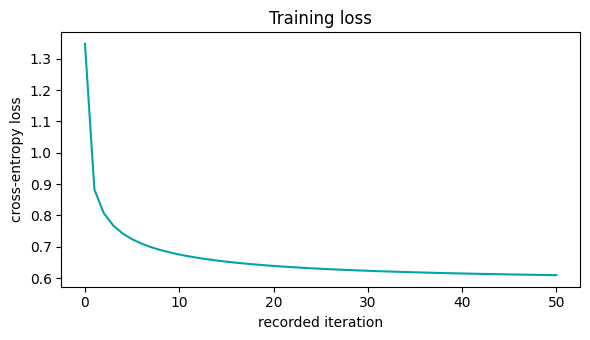

In [6]:
plt.figure(figsize=(6,3.5))
plt.plot(clf.loss_history_, color="#00A6A6")
plt.xlabel("recorded iteration"); plt.ylabel("cross-entropy loss")
plt.title("Training loss"); plt.tight_layout(); plt.show()

## 1.4 Classification metrics — from scratch

The equations (for an arbitrary class *c*):

$$\text{accuracy}=\frac{\text{correct}}{\text{all}},\quad
\text{precision}_c=\frac{TP_c}{TP_c+FP_c},\quad
\text{recall}_c=\frac{TP_c}{TP_c+FN_c},\quad
f1_c=\frac{2\,\text{precision}_c\,\text{recall}_c}{\text{precision}_c+\text{recall}_c}$$

- **Macro** average = plain mean of the per-class scores.
- **Weighted** average = mean weighted by each class's **support** (its share of the true labels).

These are the methods defined on the class above; here we call them on the held-out predictions.

In [7]:
print("accuracy            :", round(LogisticRegression.accuracy(y_test, y_pred), 4))
print("precision per class :", {k: round(v,4) for k,v in LogisticRegression.precision(y_test, y_pred).items()})
print("recall    per class :", {k: round(v,4) for k,v in LogisticRegression.recall(y_test, y_pred).items()})
print("f1        per class :", {k: round(v,4) for k,v in LogisticRegression.f1(y_test, y_pred).items()})
print()
print("macro    precision/recall/f1 :",
      round(LogisticRegression.macro_precision(y_test, y_pred),4),
      round(LogisticRegression.macro_recall(y_test, y_pred),4),
      round(LogisticRegression.macro_f1(y_test, y_pred),4))
print("weighted precision/recall/f1 :",
      round(LogisticRegression.weighted_precision(y_test, y_pred),4),
      round(LogisticRegression.weighted_recall(y_test, y_pred),4),
      round(LogisticRegression.weighted_f1(y_test, y_pred),4))

accuracy            : 0.7173
precision per class : {np.int64(0): 0.842, np.int64(1): 0.5888, np.int64(2): 0.603, np.int64(3): 0.8257}
recall    per class : {np.int64(0): 0.8397, np.int64(1): 0.6297, np.int64(2): 0.5888, np.int64(3): 0.7941}
f1        per class : {np.int64(0): 0.8408, np.int64(1): 0.6086, np.int64(2): 0.5958, np.int64(3): 0.8096}

macro    precision/recall/f1 : 0.7149 0.7131 0.7137
weighted precision/recall/f1 : 0.7199 0.7173 0.7183


Our hand-built `classification_report` reproduces the familiar sklearn layout:

In [8]:
print(LogisticRegression.classification_report(y_test, y_pred))

               precision      recall    f1-score     support

           0      0.8420      0.8397      0.8408         368
           1      0.5888      0.6297      0.6086         316
           2      0.6030      0.5888      0.5958         338
           3      0.8257      0.7941      0.8096         340

    accuracy                              0.7173        1362
   macro avg      0.7149      0.7131      0.7137        1362
weighted avg      0.7199      0.7173      0.7183        1362


## 1.5 Compare with scikit-learn's `classification_report`

We confirm both implementations agree — first on a small mock-up, then on the real predictions.

In [9]:
from sklearn.metrics import classification_report as sk_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --- mock-up data (as suggested in the brief) ---
yt = [0,1,2,3,0,1,2,3,0,0]
yp = [0,1,2,2,0,1,1,3,0,3]
print("=== mine (mock-up) ==="); print(LogisticRegression.classification_report(yt, yp, digits=2))
print("\n=== sklearn (mock-up) ==="); print(sk_report(yt, yp, zero_division=0))

=== mine (mock-up) ===
               precision      recall    f1-score     support

           0        1.00        0.75        0.86           4
           1        0.67        1.00        0.80           2
           2        0.50        0.50        0.50           2
           3        0.50        0.50        0.50           2

    accuracy                                0.70          10
   macro avg        0.67        0.69        0.66          10
weighted avg        0.73        0.70        0.70          10

=== sklearn (mock-up) ===
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.67      1.00      0.80         2
           2       0.50      0.50      0.50         2
           3       0.50      0.50      0.50         2

    accuracy                           0.70        10
   macro avg       0.67      0.69      0.66        10
weighted avg       0.73      0.70      0.70        10



In [10]:
# --- on the real held-out predictions: assert closeness ---
assert np.isclose(LogisticRegression.accuracy(y_test, y_pred), accuracy_score(y_test, y_pred))
assert np.isclose(LogisticRegression.macro_f1(y_test, y_pred), f1_score(y_test, y_pred, average="macro"))
assert np.isclose(LogisticRegression.weighted_precision(y_test, y_pred),
                  precision_score(y_test, y_pred, average="weighted", zero_division=0))
assert np.isclose(LogisticRegression.macro_recall(y_test, y_pred),
                  recall_score(y_test, y_pred, average="macro"))
print("✅ From-scratch metrics match scikit-learn on the real predictions.")

✅ From-scratch metrics match scikit-learn on the real predictions.


## 1.6 What does *support* mean in the classification report?

**Support is the number of ground-truth samples belonging to each class** — i.e. how many rows in
`y_true` actually have that label. It is the last column of the report.

Two reasons it matters:

1. It tells you **how trustworthy** each per-class score is: a precision from 3 samples is far
   noisier than one from 300.
2. It is exactly the **weight** used by the *weighted* averages — each class contributes in
   proportion to its support, which is why weighted and macro averages differ on imbalanced data.

The `accuracy`, `macro avg`, and `weighted avg` rows report the **total** support (size of the set).

In [11]:
counts = LogisticRegression._per_class_counts(y_test, y_pred)
support_table = pd.DataFrame({
    "class": list(counts.keys()),
    "label": [CLASS_LABELS[c] for c in counts],
    "support (true count)": [counts[c]["support"] for c in counts],
})
print(support_table.to_string(index=False))
print("total support =", sum(counts[c]["support"] for c in counts), "= size of the test set")

 class     label  support (true count)
     0    Budget                   368
     1 Mid-range                   316
     2   Premium                   338
     3    Luxury                   340
total support = 1362 = size of the test set


# Task 2 — Ridge (L2) Logistic Regression

Plain multinomial logistic regression has no penalty. The class above adds the **Ridge / L2** term,
controlled by `use_penalty` (on/off) and `lambda_` (strength). The penalised loss is

$$J(\theta)=-\sum_{i=1}^{m} y^{(i)}\log(h^{(i)}) \;+\; \lambda\sum_{j=1}^{n}\theta_j^{2}$$

so the gradient gains a `2·λ·θ` term (implemented in `_loss_and_gradient`; the bias row is excluded,
the standard convention of shrinking slopes only). Below we compare penalty **off** vs **on**.

In [12]:
common = dict(method="batch", learning_rate=0.1, max_iter=4000, random_state=RANDOM_STATE)

plain = LogisticRegression(use_penalty=False, **common).fit(Xtr, y_train, feature_names=feature_names)
ridge = LogisticRegression(use_penalty=True, lambda_=0.5, **common).fit(Xtr, y_train, feature_names=feature_names)

pred_plain = plain.predict(Xte)
pred_ridge = ridge.predict(Xte)

compare = pd.DataFrame({
    "metric": ["accuracy", "macro f1", "weighted f1", "sum of squared slope weights"],
    "no penalty": [
        LogisticRegression.accuracy(y_test, pred_plain),
        LogisticRegression.macro_f1(y_test, pred_plain),
        LogisticRegression.weighted_f1(y_test, pred_plain),
        float(np.sum(plain.weights[1:]**2)),
    ],
    "ridge (λ=0.5)": [
        LogisticRegression.accuracy(y_test, pred_ridge),
        LogisticRegression.macro_f1(y_test, pred_ridge),
        LogisticRegression.weighted_f1(y_test, pred_ridge),
        float(np.sum(ridge.weights[1:]**2)),
    ],
})
compare.round(4)

,metric,no penalty,ridge (λ=0.5)
0,accuracy,0.7173,0.5815
1,macro f1,0.7137,0.4875
2,weighted f1,0.7183,0.5003
3,sum of squared slope weights,79.1743,0.1573


As expected, the Ridge penalty **shrinks the weight magnitudes** (smaller sum of squared
weights), trading a little training fit for a simpler, better-regularised model. `use_penalty=False`
recovers ordinary multinomial logistic regression.

# Task 3 — Deployment

## Objective 1 — Log the experiment to MLflow

We sweep gradient-descent **method** × **penalty on/off** × **learning rate** × **λ**, cross-validate
each configuration with stratified K-fold, and log params + metrics to MLflow. The full experiment
code is written inline below.

**Server status:** the CSIM server is down (TA notice), so we log **locally** to a sqlite store. To
switch to the server once restored, change one line:

```python
tracking_uri = "http://mlflow.ml.brain.cs.ait.ac.th/"   # instead of sqlite:///mlflow.db
```
The experiment name is `st127004-a3`, as required.

In [13]:
def configuration_grid():
    """method x penalty x learning_rate x lambda (lambda ignored when penalty off)."""
    grid = []
    for method, use_penalty, lr, lam in product(
        ["batch", "minibatch", "stochastic"], [False, True], [0.1, 0.05, 0.01], [0.01, 0.1]
    ):
        if not use_penalty and lam != 0.01:          # avoid duplicate no-penalty runs
            continue
        grid.append({"method": method, "use_penalty": use_penalty,
                     "learning_rate": lr, "lambda_": lam})
    return grid


def cross_validate_configuration(features, labels, cfg, folds=3, max_iter=1500, seed=RANDOM_STATE):
    """Stratified CV of one configuration with fold-local preprocessing (no leakage)."""
    labels = np.asarray(labels)
    splitter = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    scores = []
    for i, (tr, va) in enumerate(splitter.split(features, labels)):
        prep = build_preprocessor()
        Xt = prep.fit_transform(features.iloc[tr]); Xv = prep.transform(features.iloc[va])
        names = list(prep.get_feature_names_out())
        model = LogisticRegression(method=cfg["method"], learning_rate=cfg["learning_rate"],
                                   max_iter=max_iter, use_penalty=cfg["use_penalty"],
                                   lambda_=cfg["lambda_"], random_state=seed + i)
        model.fit(Xt, labels[tr], feature_names=names)
        p = model.predict(Xv); t = labels[va]
        scores.append({"cv_accuracy": model.accuracy(t, p),
                       "cv_macro_f1": model.macro_f1(t, p),
                       "cv_weighted_f1": model.weighted_f1(t, p)})
    return {k: float(np.mean([s[k] for s in scores])) for k in scores[0]}

In [14]:
import mlflow

TRACKING_URI = f"sqlite:///{Path('mlflow.db').resolve().as_posix()}"
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("st127004-a3")

# Keep the notebook quick: run a representative subset here (6 of 27 runs) with
# fewer iterations. run_a3_experiment.py runs the full grid and saves artifacts.
subset = configuration_grid()[:6]
records = []
for i, cfg in enumerate(subset, start=1):
    tag = "L2" if cfg["use_penalty"] else "none"
    with mlflow.start_run(run_name=f"run-{i:03d}-{cfg['method']}-{tag}") as run:
        metrics = cross_validate_configuration(X_train, y_train, cfg, folds=3, max_iter=800)
        mlflow.log_params({**cfg, "folds": 3, "max_iter": 800, "seed": RANDOM_STATE})
        mlflow.log_metrics(metrics)
        mlflow.set_tag("assignment", "A3 Predicting Car Price - Classification")
        records.append({**cfg, **metrics, "run_id": run.info.run_id})

results = (pd.DataFrame(records)
           .sort_values(["cv_accuracy", "cv_macro_f1"], ascending=False)
           .reset_index(drop=True))
results.round(4)

,method,use_penalty,learning_rate,lambda_,cv_accuracy,cv_macro_f1,cv_weighted_f1,run_id
0,batch,False,0.10,0.01,0.7284,0.7231,0.7277,32d82e0eda8c4096895b80922b9f39f6
1,batch,False,0.05,0.01,0.7169,0.7094,0.7143,461ecc4bcecd4d6391c573fd6cc062b2
2,batch,True,0.10,0.01,0.7154,0.7061,0.7112,b55b509fcfd344e084f7551134fb7d44
3,batch,True,0.05,0.01,0.7068,0.6960,0.7013,118d5b60d96e4794a1633e5c85478088
4,batch,False,0.01,0.01,0.6586,0.6359,0.6425,5441970060da46c2a0342f702bcd8ce6
5,batch,True,0.10,0.10,0.6403,0.6017,0.6101,f4da918684684a6aa83a562d7cbcbda8


> The **full** 27-configuration sweep is produced by `run_a3_experiment.py`; its ranked results
> are saved to `artifacts/cv_results.csv` and summarised in `artifacts/experiment_summary.json`.
> Inspect the runs with:
> ```
> mlflow server --backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000
> ```

## Objective 1 (cont.) — Fit and save the best model

We refit the best configuration on the full training split and save the bundle
(preprocessor + classifier + class bin edges) that the web app serves.

In [15]:
import joblib

best = results.iloc[0][["method", "use_penalty", "learning_rate", "lambda_"]].to_dict()
best["use_penalty"] = bool(best["use_penalty"])
print("Best (subset) configuration:", best)

final_pre = build_preprocessor()
final_Xtr = final_pre.fit_transform(X_train)
final_names = list(final_pre.get_feature_names_out())
final_model = LogisticRegression(method=best["method"], learning_rate=best["learning_rate"],
                                 max_iter=4000, use_penalty=best["use_penalty"],
                                 lambda_=best["lambda_"], random_state=RANDOM_STATE)
final_model.fit(final_Xtr, y_train, feature_names=final_names)

test_pred = final_model.predict(final_pre.transform(X_test))
print(f"Held-out test accuracy: {LogisticRegression.accuracy(y_test, test_pred):.4f}")
print(f"Held-out macro f1     : {LogisticRegression.macro_f1(y_test, test_pred):.4f}")

bundle = {"preprocessor": final_pre, "model": final_model, "feature_names": final_names,
          "configuration": best, "bin_edges": np.asarray(bin_edges, dtype=float),
          "class_labels": CLASS_LABELS}
# (run_a3_experiment.py is what writes model/a3_car_price_classifier.pkl used by the app.)
print("\nBundle keys:", list(bundle.keys()))

Best (subset) configuration: {'method': 'batch', 'use_penalty': False, 'learning_rate': 0.1, 'lambda_': 0.01}


Held-out test accuracy: 0.7173
Held-out macro f1     : 0.7137

Bundle keys: ['preprocessor', 'model', 'feature_names', 'configuration', 'bin_edges', 'class_labels']


## Objective 2 — Model registry (deferred)

Registering the best run to MLflow **Models** as `st127004-a3-model` at the *Staging* stage requires
the CSIM tracking/registry server, which is currently down. Per the TA, this is deferred until the
server is restored; the local runs above are ready to be registered with a single
`mlflow.register_model(...)` call once it is back.

## Objective 3 — CI/CD (complete)

`.github/workflows/ci-cd.yml` implements the pipeline:

1. **CI** — every push runs `pytest` over `tests/` and `app/code/tests/`. The two required model
   unit tests live in `app/code/tests/test_predict.py`:
   * `test_model_takes_expected_input` — the model accepts the expected input, and
   * `test_model_output_has_expected_shape` — `predict_proba` returns shape `(n, 4)`.
2. **CD** — if the tests pass on `main`, the workflow builds the Docker image, pushes it to Docker
   Hub, and SSH-deploys it to the CSIM server behind Traefik.

See the README for the GitHub Secrets the pipeline needs.

---

### Summary

- 4-class problem via price quartiles; multinomial logistic regression **from scratch**.
- Every metric hand-implemented and **verified against scikit-learn**.
- Optional **Ridge (L2)** penalty that demonstrably shrinks the weights.
- MLflow experiment (local for now), model bundle saved, and a full **CI/CD** pipeline.
